# 2. Your first number

Notebook 01 recovered mutual information in high dimensions from a workable
number of samples. That estimate came out of a trained network and depends on
how the training went. This notebook takes one such number apart into the things
that decide it:

- **The data:** How many samples you have, how many latent dimensions carry the
structure, how much information those dimensions hold, and how many channels
you recorded. None of these are yours to choose and most of them are invisible.

- **The training:** How long to train, how wide to make the embedding, and how to
read the variance and the bias of the estimator. All of these are yours to set.

Part I measures what the data allows before any of your choices enter. Part II
works through the choices themselves.

## Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import neural_mi as nmi

## Cost knobs

The knobs marked load-bearing carry their section's result. The rest trade
precision for time.

In [2]:
# --- Cost knobs -----------------------------------------------------------
# Safe to reduce. These cost precision and leave the conclusions standing.

LATENT_DIM   = 10           # latent dimensions carrying the structure
OBSERVED_DIM = 500          # channels the latent is observed through
TRUE_MI      = 4.0          # bits, by construction
N_SAMPLES    = 2_000        # samples in the baseline problem
EMBED_DIM    = 32           # embedding width for the baseline runs
HIDDEN_DIM   = 256
N_EPOCHS     = 150
BATCH_SIZE   = 128

CURVE_EPOCHS = 200          # section 3 trains this long with early stopping off
STARVED_N    = 400          # the undersampled case, sections 5 and 6
HIGH_MI      = 10.0         # section 6's ceiling case
WEAK_MI      = 0.5          # the weak-signal case, sections 2 and 4

GRID_N       = [50, 100, 200, 400, 800, 1600]   # section 2's sample axis
GRID_LATENT  = [5, 10, 20]                      # section 2's latent axis
OBS_SWEEP    = [50, 100, 500, 1000]             # section 2's channel panel
MI_SWEEP     = [0.5, 1.0, 2.0, 4.0, 8.0]        # section 2's information panel

# Load-bearing.

N_SEEDS = 3
# Section 2 reads the spread across independent draws of the data. A single
# draw shows nothing: the sample-size effect lives entirely in that spread.

EMBED_SWEEP = [2, 4, 8, 16, 32, 64]
# Section 4 needs values below and above the latent dimension. Drop the small
# end and the collapse goes, drop the large end and the recovery goes.

SEED = 0

N_WORKERS = 4
# How many runs go at once. Set it to your core count: every repeat below is an
# independent job and the library dispatches them to a pool.

# Heavy cells: section 2's grid and the two panels after it.

## 1. One estimate from data to number

We start with the same dataset as notebook 01. A latent pair is drawn jointly
Gaussian in $d$ dimensions with a chosen mutual information between the two
halves. Each half then goes through its own random nonlinear map into $D \gg d$
observed channels,

$$\begin{pmatrix} z^{x} \\ z^{y} \end{pmatrix} \;\sim\;
  \mathcal{N}\!\left(0,\;
  \begin{pmatrix} I_d & \rho I_d \\ \rho I_d & I_d \end{pmatrix}\right),
  \qquad x = f_x\bigl(z^{x}\bigr), \qquad y = f_y\bigl(z^{y}\bigr),$$

with $\rho = \sqrt{1 - 2^{-2I/d}}$ fixing the latent value and $f_x, f_y$ a pair
of random two-layer softplus networks. Because mutual information survives a
smooth invertible map, the observed pair carries roughly the same information as
the latent pair underneath it.

The estimator never sees the latent variable and has to work its way back to
that structure from the observed channels alone.

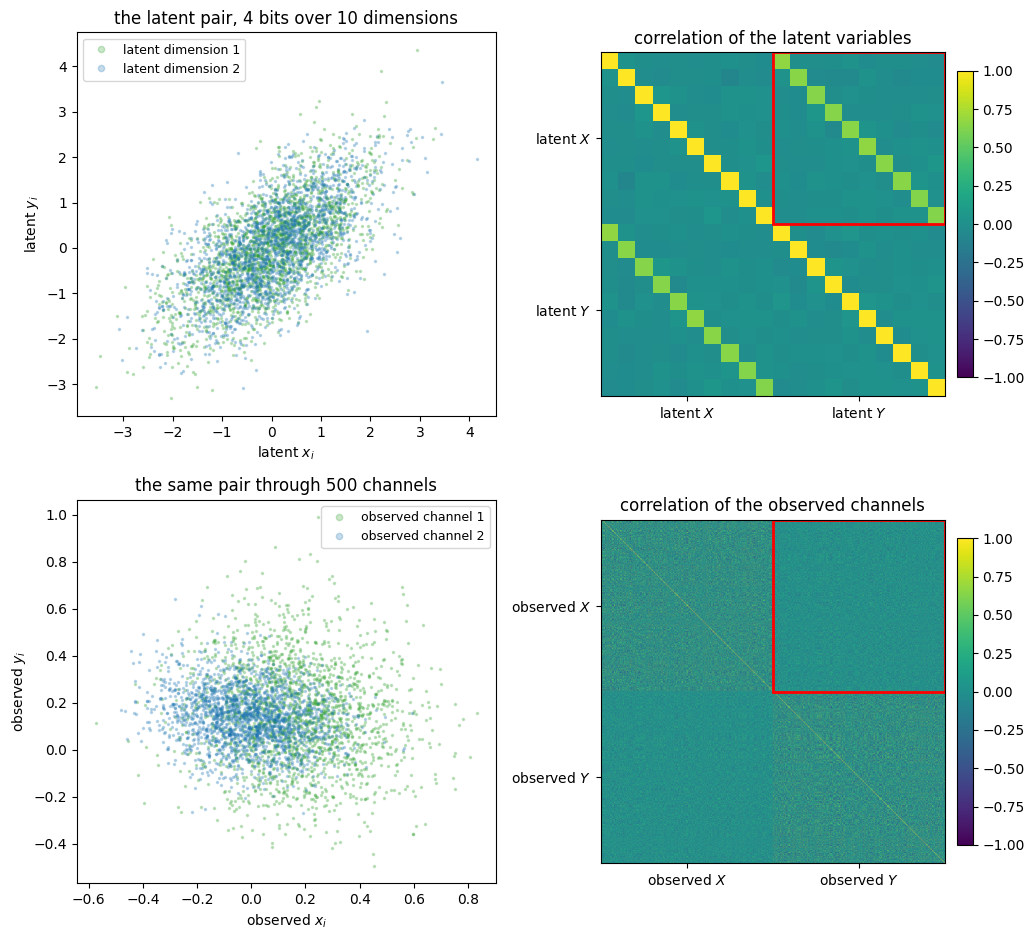

latent   x torch.Size([2000, 10])  y torch.Size([2000, 10])   exact I = 4.00 bits
observed x torch.Size([2000, 500])  y torch.Size([2000, 500])   same 4.00 bits
largest |correlation| between any observed x and y channel: 0.613


In [3]:
def make_data(n_samples=None, latent_dim=None, observed_dim=None, mi=None,
              seed=SEED, latents=False):
    """The notebook's one dataset, with every property exposed as an argument."""
    out = nmi.generators.generate_nonlinear_from_latent(
        n_samples=n_samples or N_SAMPLES,
        latent_dim=latent_dim or LATENT_DIM,
        observed_dim=observed_dim or OBSERVED_DIM,
        mi=TRUE_MI if mi is None else mi,
        return_latents=latents, seed=seed)
    return out


x, y, zx, zy = make_data(latents=True)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 9.5))

axes[0, 0].plot(zx[:, 0], zy[:, 0], '.', ms=3, alpha=0.25, color='tab:green',
                label='latent dimension 1')
axes[0, 0].plot(zx[:, 1], zy[:, 1], '.', ms=3, alpha=0.25, color='tab:blue',
                label='latent dimension 2')
axes[0, 0].set_xlabel('latent $x_i$')
axes[0, 0].set_ylabel('latent $y_i$')
axes[0, 0].set_title(f'the latent pair, {TRUE_MI:.0f} bits over {LATENT_DIM} dimensions')
axes[0, 0].legend(markerscale=3, fontsize=9)

cor_z = np.corrcoef(zx.T, zy.T)
im = axes[0, 1].imshow(cor_z, cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[0, 1], shrink=0.8, pad=0.03)
axes[0, 1].add_patch(Rectangle((LATENT_DIM - 0.5, -0.5), LATENT_DIM, LATENT_DIM,
                               fill=False, color='r', lw=2))
axes[0, 1].set_xticks([(LATENT_DIM - 1) / 2, LATENT_DIM + (LATENT_DIM - 1) / 2])
axes[0, 1].set_xticklabels(['latent $X$', 'latent $Y$'])
axes[0, 1].set_yticks([(LATENT_DIM - 1) / 2, LATENT_DIM + (LATENT_DIM - 1) / 2])
axes[0, 1].set_yticklabels(['latent $X$', 'latent $Y$'])
axes[0, 1].set_title('correlation of the latent variables')

axes[1, 0].plot(x[:, 0], y[:, 0], '.', ms=3, alpha=0.25, color='tab:green',
                label='observed channel 1')
axes[1, 0].plot(x[:, 1], y[:, 1], '.', ms=3, alpha=0.25, color='tab:blue',
                label='observed channel 2')
axes[1, 0].set_xlabel('observed $x_i$')
axes[1, 0].set_ylabel('observed $y_i$')
axes[1, 0].set_title(f'the same pair through {OBSERVED_DIM} channels')
axes[1, 0].legend(markerscale=3, fontsize=9)

cor_o = np.corrcoef(x.T, y.T)
im = axes[1, 1].imshow(cor_o, cmap='viridis', vmin=-1, vmax=1)
plt.colorbar(im, ax=axes[1, 1], shrink=0.8, pad=0.03)
axes[1, 1].add_patch(Rectangle((OBSERVED_DIM - 0.5, -0.5), OBSERVED_DIM, OBSERVED_DIM,
                               fill=False, color='r', lw=2))
axes[1, 1].set_xticks([(OBSERVED_DIM - 1) / 2, OBSERVED_DIM + (OBSERVED_DIM - 1) / 2])
axes[1, 1].set_xticklabels(['observed $X$', 'observed $Y$'])
axes[1, 1].set_yticks([(OBSERVED_DIM - 1) / 2, OBSERVED_DIM + (OBSERVED_DIM - 1) / 2])
axes[1, 1].set_yticklabels(['observed $X$', 'observed $Y$'])
axes[1, 1].set_title('correlation of the observed channels')

fig.tight_layout()
plt.show()

print(f"latent   x {zx.shape}  y {zy.shape}   exact I = {TRUE_MI:.2f} bits")
print(f"observed x {x.shape}  y {y.shape}   same {TRUE_MI:.2f} bits")
print(f"largest |correlation| between any observed x and y channel: "
      f"{np.abs(cor_o[:OBSERVED_DIM, OBSERVED_DIM:]).max():.3f}")

- **Top left:** Two latent dimensions against their partners. We can see some modest dependence.
- **Top right:** The correlation matrix of the latent variables. The boxed
  block is what the two halves share that carries MI.
- **Bottom left:** The same two indices after the nonlinear map, now two
  observed channels out of five hundred.
- **Bottom right:** The correlation matrix of the observed channels. The boxed
  block has no diagonal left in it.

In principle, nothing was lost between the top row and the bottom row. The map spread the
same four bits across five hundred channels in a form that no pairwise
correlation picks up.

In [4]:
model    = nmi.Model(hidden_dim=HIDDEN_DIM, embedding_dim=EMBED_DIM)
training = nmi.Training(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, patience=30,
                        learning_rate=1e-3, eval_train='full')

t0 = time.time()
result = nmi.run(x, y, mode='estimate',
                 model=model, training=training,
                 split=nmi.Split(mode='random'),
                 estimator=nmi.Estimator('infonce'),
                 n_workers=1, seed=SEED, show_progress=True)

print(f"exact I(X; Y) : {TRUE_MI:.4f} bits")
print(f"mi_estimate   : {result.mi_estimate:.4f} bits")
print(f"({time.time() - t0:.0f}s)")

exact I(X; Y) : 4.0000 bits
mi_estimate   : 3.8477 bits
(6s)


The estimate lands within a few percent of the value the generator put in.

Its units are bits per observation of one instant of $X$ against one instant of
$Y$. Since a bit is one yes-or-no question answered, an estimate of one bit says
that knowing $X$ halves the possibilities left for $Y$.

**Note:** Three other normalisations appear later in the series. Bits per
observation applies here because the samples are independent and you don't need
to observe a window of the data. This is very unlikely for true neural data in
which each time point shares something with the one next to it. Notebooks 03 and
04 introduce the rest.

## Part I. What the data allows

## 2. Four properties of the data

Whether the information in a dataset can be recovered, and how well, depends on
the number of samples, the number of latent dimensions carrying the structure,
the total information those dimensions hold, and the number of channels they
were observed through. The last one has the least effect although it is the only
one visible to you before you start.

Each sweep moves one property and holds the others at the baseline from section
1. Every point is drawn three times from independent samples of the data so we
can see the spread.

In [5]:
def estimate_ratio(n_samples, latent_dim, observed_dim, mi, seed):
    # This one stays a loop. Every other repeat in the course is a
    # sweep_grid={'run_id': ...} that re-runs the training on fixed data.
    # Here the seed also redraws the data, and the spread across independent
    # draws is the whole measurement, so the repeats cannot move inside a sweep.
    #
    # embedding_dim scales with the latent dimension so this measures the data
    # and not an under-provisioned embedding. Section 4 covers that setting.
    xs, ys = make_data(n_samples=n_samples, latent_dim=latent_dim,
                       observed_dim=observed_dim, mi=mi, seed=seed)
    r = nmi.run(xs, ys, mode='estimate',
                model=nmi.Model(hidden_dim=HIDDEN_DIM,
                                embedding_dim=max(EMBED_DIM, 3 * latent_dim)),
                training=nmi.Training(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                                      patience=30, learning_rate=1e-3),
                split=nmi.Split(mode='random'),
                estimator=nmi.Estimator('infonce'),
                n_workers=1, seed=seed, show_progress=False)
    return r.mi_estimate / mi


# --- samples against latent dimension ---------------------------------------
t0 = time.time()
grid = {}
print(f"{'latent':>7} {'N':>6} {'mean':>7} {'sd':>7}   draws")
for d in GRID_LATENT:
    for n in GRID_N:
        vals = np.array([estimate_ratio(n, d, OBSERVED_DIM, TRUE_MI, s)
                         for s in range(N_SEEDS)])
        grid[(d, n)] = vals
        print(f"{d:>7} {n:>6} {vals.mean():>7.3f} {vals.std(ddof=1):>7.3f}   "
              f"{np.round(vals, 2)}", flush=True)
print(f"({time.time() - t0:.0f}s)")

 latent      N    mean      sd   draws


ipykernel_61779/4063717976.py:11: UserWarning: Only 50 samples reach the estimator. The samples an estimate needs grow roughly as N ~ d^2/I (tutorial 02, section 2). Here d is the number of latent dimensions carrying the shared information and I is the information itself. Neither is known before estimating. A few latent dimensions carrying several bits can settle within a few hundred samples. Many dimensions or little information need far more. mode='rigorous' tests whether the estimate still moves with the sample size. At this size regularisation also helps: dropout=0.2; norm_layer='layer'; hidden_dim=32 (current: 256); optimizer='adamw' with optimizer_params={'weight_decay': 1e-3}.
  r = nmi.run(xs, ys, mode='estimate',
ipykernel_61779/4063717976.py:11: UserWarning: batch_size=128 exceeds the 45 training samples available and is capped to 45. Batch size sets how many negatives each training step sees. A batch cannot hold more samples than the training set. A longer recording, a small

2026-09-30 17:43:04 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: test MI (2.009 bits) vs. test ceiling log(test_eval_size=5)=2.322 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


      5     50   0.933   0.171   [0.97 0.75 1.08]


      5    100   0.974   0.067   [0.99 0.9  1.03]


...

     20   1600   1.175   0.074   [1.22 1.09 1.22]


2026-09-30 17:44:49 - neural_mi - WARNING - 'Only 50 samples reach the estimator' was raised 12 times in this cell and shown once.


2026-09-30 17:44:49 - neural_mi - WARNING - 'batch_size=128 exceeds the 45 training samples available and is capped to 45' was raised 18 times in this cell and shown once.


2026-09-30 17:44:49 - neural_mi - WARNING - 'Only 50 samples reach the estimator' was raised 6 times in this cell and shown once.


(106s)


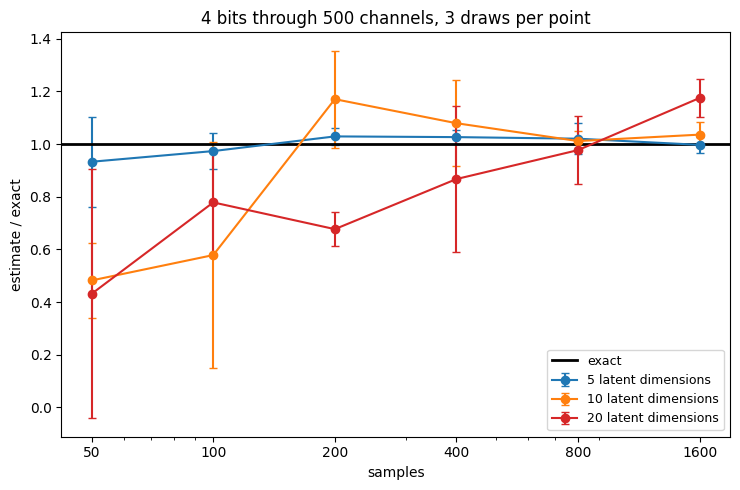

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for d, colour in zip(GRID_LATENT, ('tab:blue', 'tab:orange', 'tab:red')):
    means = [grid[(d, n)].mean() for n in GRID_N]
    sds   = [grid[(d, n)].std(ddof=1) for n in GRID_N]
    ax.errorbar(GRID_N, means, yerr=sds, fmt='o-', capsize=3, color=colour,
                label=f'{d} latent dimensions')
ax.axhline(1.0, color='k', lw=2, label='exact')
ax.set_xscale('log')
ax.set_xticks(GRID_N)
ax.set_xticklabels(GRID_N)
ax.set_xlabel('samples')
ax.set_ylabel('estimate / exact')
ax.set_title(f'{TRUE_MI:.0f} bits through {OBSERVED_DIM} channels, '
             f'{N_SEEDS} draws per point')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Each curve tightens onto the exact value once the sample is large enough for
its latent dimension. The sample size where that happens moves between the
three curves. Five latent dimensions settle by ~two hundred samples, ten need
~eight hundred, and twenty have not settled anywhere in the range swept.

Doubling the latent dimension from five to ten multiplied the sample requirement
by about four. Doubling it again puts the requirement past the end of this
sweep. The appendix of [Abdelaleem et al.
(2025)](https://arxiv.org/abs/2506.00330) derives that scaling for a spike model
using random matrix theory,

$$N \;\sim\; \frac{d^{2}}{I},$$

with $d$ the number of latent dimensions and $I$ the total information. Real
data will not follow that expression exactly. What it gives you is the list of
quantities that set the difficulty, together with how fast the cost climbs in
each one.

**Note:** The observed dimension does not appear in that formula. The next two
sweeps check whether it appears in the answer.

In [7]:
t0 = time.time()
obs_res = {n_obs: np.array([estimate_ratio(N_SAMPLES, LATENT_DIM, n_obs, TRUE_MI, s)
                            for s in range(N_SEEDS)])
           for n_obs in OBS_SWEEP}
mi_res  = {m: np.array([estimate_ratio(N_SAMPLES, LATENT_DIM, OBSERVED_DIM, m, s)
                        for s in range(N_SEEDS)])
           for m in MI_SWEEP}

print(f"{'channels':>9} {'mean':>7} {'sd':>7}")
for n_obs in OBS_SWEEP:
    print(f"{n_obs:>9} {obs_res[n_obs].mean():>7.3f} {obs_res[n_obs].std(ddof=1):>7.3f}")
print()
print(f"{'bits':>9} {'mean':>7} {'sd':>7}")
for m in MI_SWEEP:
    print(f"{m:>9.1f} {mi_res[m].mean():>7.3f} {mi_res[m].std(ddof=1):>7.3f}")
print(f"({time.time() - t0:.0f}s)")

 channels    mean      sd
       50   1.022   0.028
      100   1.031   0.027
      500   1.023   0.063
     1000   1.024   0.030

     bits    mean      sd
      0.5   1.281   0.086
      1.0   1.110   0.058
      2.0   1.110   0.046
      4.0   1.023   0.063
      8.0   0.927   0.014
(183s)


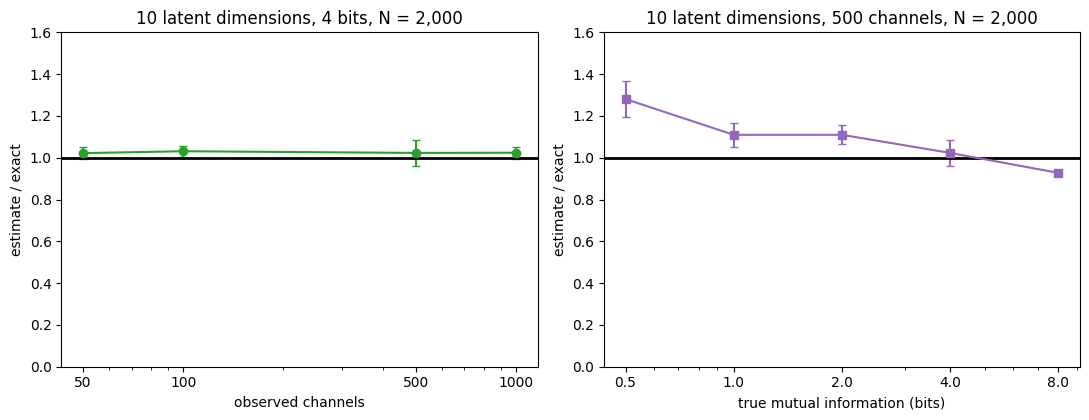

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

axes[0].errorbar(OBS_SWEEP, [obs_res[n].mean() for n in OBS_SWEEP],
                 yerr=[obs_res[n].std(ddof=1) for n in OBS_SWEEP],
                 fmt='o-', capsize=3, color='tab:green')
axes[0].axhline(1.0, color='k', lw=2)
axes[0].set_xscale('log')
axes[0].set_xticks(OBS_SWEEP)
axes[0].set_xticklabels(OBS_SWEEP)
axes[0].set_xlabel('observed channels')
axes[0].set_ylabel('estimate / exact')
axes[0].set_ylim(0, 1.6)
axes[0].set_title(f'{LATENT_DIM} latent dimensions, {TRUE_MI:.0f} bits, '
                  f'N = {N_SAMPLES:,}')

axes[1].errorbar(MI_SWEEP, [mi_res[m].mean() for m in MI_SWEEP],
                 yerr=[mi_res[m].std(ddof=1) for m in MI_SWEEP],
                 fmt='s-', capsize=3, color='tab:purple')
axes[1].axhline(1.0, color='k', lw=2)
axes[1].set_xscale('log')
axes[1].set_xticks(MI_SWEEP)
axes[1].set_xticklabels(MI_SWEEP)
axes[1].set_xlabel('true mutual information (bits)')
axes[1].set_ylabel('estimate / exact')
axes[1].set_ylim(0, 1.6)
axes[1].set_title(f'{LATENT_DIM} latent dimensions, {OBSERVED_DIM} channels, '
                  f'N = {N_SAMPLES:,}')

fig.tight_layout()
plt.show()

- **Left:** Twenty times the channels doesn't change the estimate or its
  spread that much. Once the latent structure is
  fixed and we can sample it well enough, the number of observed dimensions doesn't make a difference.
- **Right:** Weak information reads high and strong information reads slightly
  low.

That overshoot is finite-size fluctuation counted as signal. Two independent
variables show some correlation in any finite sample. An information estimate
near that floor cannot tell the two apart. Sections 5 and 6 measure how close to
the floor a given run is sitting.

Everything in this section was outside your control. The rest of the notebook
covers the settings that are inside it.

## Part II. What you control

## 3. How long to train

The estimate comes out of training a network (in fact two, or one or three
depending on the critic type). Training runs for a number of epochs that are
each a full pass over the data. Past some point the network starts fitting the
sample instead of the distribution. The usual answer is to split the data, watch
a held-out partition, and report the held-out number.

For mutual information, the quantity is a property of the distribution of the
data we're using for the training. The held-out curve is the diagnostic that
picks the epoch at which the network starts to overfit. The training-side value
at that epoch is the estimate. We call this the max-test heuristic.

The procedure then is:

1. After each epoch, evaluate MI on the held-out partition.
2. Smooth that curve and find where the smoothed version peaks.
3. Return to the weights at that epoch, evaluate on the training partition, and
   report that value.

[Abdelaleem et al. (2025)](https://arxiv.org/abs/2506.00330) argue the case in detail.

**Note:** The smoothing stops one lucky epoch from deciding the answer. The
procedure involves some choices and is likely not the only reasonable one.

In [9]:
# Early stopping is switched off here so the whole curve is visible. With the
# default patience the run halts near the peak and the decay never gets drawn.
t0 = time.time()
curve = nmi.run(x, y, mode='estimate',
                model=model,
                training=nmi.Training(n_epochs=CURVE_EPOCHS, batch_size=BATCH_SIZE,
                                      patience=CURVE_EPOCHS, learning_rate=1e-3,
                                      eval_train='full'),
                split=nmi.Split(mode='random'),
                estimator=nmi.Estimator('infonce'),
                n_workers=1, seed=SEED, show_progress=True)

test_hist  = np.asarray(curve.get('test_mi_history'))
train_hist = np.asarray(curve.get('train_mi_history'))
best       = curve.get('best_epoch')

print(f"epochs run                : {len(test_hist)}")
print(f"best_epoch (smoothed)     : {best}")
print(f"argmax of the raw test MI : {int(np.argmax(test_hist))}")
print()
print(f"held-out MI at best_epoch : {test_hist[best]:.4f} bits")
print(f"train MI at best_epoch    : {train_hist[best]:.4f} bits")
print(f"train MI at the last epoch: {train_hist[-1]:.4f} bits")
print(f"mi_estimate               : {curve.mi_estimate:.4f} bits")
print(f"result.get('test_mi')     : {curve.get('test_mi'):.4f} bits")
print(f"exact                     : {TRUE_MI:.4f} bits")
print(f"({time.time() - t0:.0f}s)")

epochs run                : 200
best_epoch (smoothed)     : 21
argmax of the raw test MI : 20

held-out MI at best_epoch : 3.2592 bits
train MI at best_epoch    : 3.6714 bits
train MI at the last epoch: 5.1674 bits
mi_estimate               : 3.8477 bits
result.get('test_mi')     : 3.5967 bits
exact                     : 4.0000 bits
(19s)


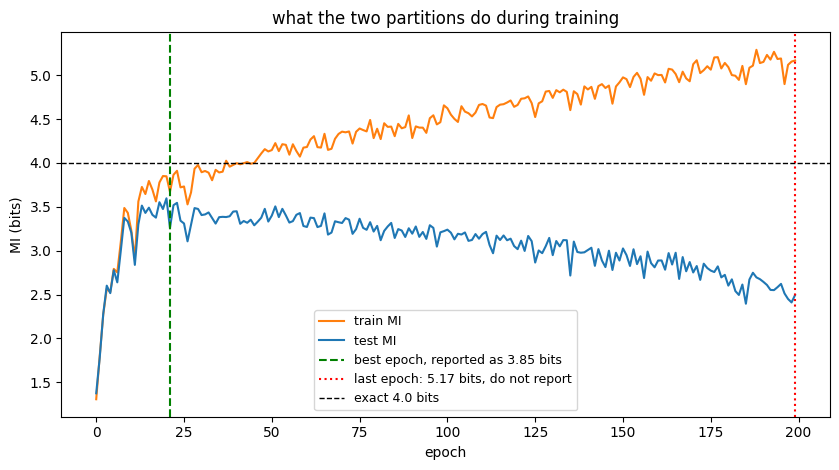

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(train_hist, color='tab:orange', label='train MI')
ax.plot(test_hist, color='tab:blue', label='test MI')
ax.axvline(best, color='g', ls='--', lw=1.5,
           label=f'best epoch, reported as {curve.mi_estimate:.2f} bits')
ax.axvline(len(train_hist) - 1, color='r', ls=':', lw=1.5,
           label=f'last epoch: {train_hist[-1]:.2f} bits, do not report')
ax.axhline(TRUE_MI, color='k', ls='--', lw=1, label=f'exact {TRUE_MI:.1f} bits')
ax.set_xlabel('epoch')
ax.set_ylabel('MI (bits)')
ax.set_title('what the two partitions do during training')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The two curves separate after about a dozen epochs. The held-out curve rises to
a peak and then falls away for the rest of training. The training curve climbs
steadily and is still climbing when the epoch budget runs out.

The reported value is the training curve read at the epoch where the held-out
curve peaked. The second marked line is what training to the end would have
given you. `mi_estimate` sits close to the tracked training value at that epoch
without matching it exactly. The reported number comes from a fresh evaluation
after training. The tracked value came from the per-epoch pass.

Picking the epoch is the whole of `test_mi`'s job. Because tracking `train_mi`
during training is not needed for it, the library leaves it off by default. You
can turn it on from `eval_train`.

## 4. How wide to make the embedding

The estimator maps each variable into an embedding and measures information
between the embeddings. That embedding has to be wide enough to hold the
structure it is being asked to represent.

`mode='sweep'` runs the same call across a grid of settings. Sweeping
`embedding_dim` through and past the latent dimension shows what each side of
it looks like. The sweep runs twice, once at the full information and once at
the weak setting from section 2.

In [11]:
def embedding_sweep(mi):
    xs, ys = make_data(mi=mi)
    return nmi.run(xs, ys, mode='sweep',
                   sweep_grid={'embedding_dim': EMBED_SWEEP},
                   model=model,
                   training=nmi.Training(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                                         patience=30, learning_rate=1e-3),
                   split=nmi.Split(mode='random'),
                   estimator=nmi.Estimator('infonce'),
                   n_workers=N_WORKERS, seed=SEED, show_progress=False)


t0 = time.time()
sweep_strong = embedding_sweep(TRUE_MI)
sweep_weak   = embedding_sweep(WEAK_MI)

print(f"latent dimension {LATENT_DIM}, {N_SAMPLES:,} samples")
print(f"{'embedding':>10} {'at ' + f'{TRUE_MI:.0f}' + ' bits':>14} "
      f"{'at ' + f'{WEAK_MI}' + ' bits':>14}")
for e in EMBED_SWEEP:
    s = sweep_strong.dataframe.set_index('embedding_dim').loc[e, 'mi_mean']
    w = sweep_weak.dataframe.set_index('embedding_dim').loc[e, 'mi_mean']
    print(f"{e:>10} {s / TRUE_MI:>14.3f} {w / WEAK_MI:>14.3f}")
print(f"({time.time() - t0:.0f}s)")

latent dimension 10, 2,000 samples
 embedding      at 4 bits    at 0.5 bits
         2          0.187          0.252
         4          0.393          0.624
         8          0.738          0.878
        16          1.035          1.291
        32          0.997          1.299
        64          1.003          1.079
(32s)


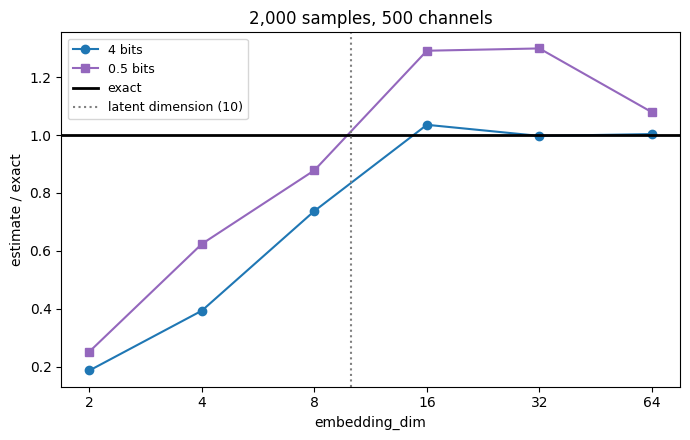

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
strong = sweep_strong.dataframe.set_index('embedding_dim')['mi_mean'] / TRUE_MI
weak   = sweep_weak.dataframe.set_index('embedding_dim')['mi_mean'] / WEAK_MI
ax.plot(strong.index, strong.values, 'o-', color='tab:blue',
        label=f'{TRUE_MI:.0f} bits')
ax.plot(weak.index, weak.values, 's-', color='tab:purple',
        label=f'{WEAK_MI} bits')
ax.axhline(1.0, color='k', lw=2, label='exact')
ax.axvline(LATENT_DIM, color='grey', ls=':',
           label=f'latent dimension ({LATENT_DIM})')
ax.set_xscale('log', base=2)
ax.set_xticks(EMBED_SWEEP)
ax.set_xticklabels(EMBED_SWEEP)
ax.set_xlabel('embedding_dim')
ax.set_ylabel('estimate / exact')
ax.set_title(f'{N_SAMPLES:,} samples, {OBSERVED_DIM} channels')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Below the latent dimension the estimate silently collapses well short of the
truth. If the embedding dimension is fixed below the true one, the result is
always an underestimate that nothing flags. At four bits the curve flattens onto
the exact value from an embedding of sixteen upward and holds there through
sixty-four. Extra width is free once the structure fits.

At half a bit the same sweep overshoots because it's harder to find
weaker MI values and the allowed extra dimensions are not helping.

You will not know the latent dimension of your own data. Err wide and treat an
answer that moves with the embedding as one that has not converged. Being
generous with the embedding dimension is generally safe. Past some point the
initialisation noise carried by the extra dimensions can make the optimiser's
job harder in a way that shows up soonest in the low-MI situation above.

## 5. The spread across repeats

Retraining the same model on the same data from a different initialisation
gives a different number.

The sweep variable `run_id` means "do it again" and gives multiple repeats. The
same call runs at the baseline sample size and at the starved one from section
2.

In [13]:
def seed_spread(n_samples):
    xs, ys = make_data(n_samples=n_samples)
    return nmi.run(xs, ys, mode='sweep',
                   sweep_grid={'run_id': list(range(5))},
                   model=model,
                   training=nmi.Training(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                                         patience=30, learning_rate=1e-3),
                   split=nmi.Split(mode='random'),
                   estimator=nmi.Estimator('infonce'),
                   n_workers=5, seed=SEED, show_progress=False)


t0 = time.time()
spreads = {n: seed_spread(n) for n in (STARVED_N, N_SAMPLES)}

print(f"{'N':>7} {'mean':>8} {'sd':>8} {'relative':>10}   runs")
for n, res in spreads.items():
    v = res.runs['mi'].to_numpy()        # one value per repeat
    print(f"{n:>7,} {v.mean():>8.3f} {v.std(ddof=1):>8.3f} "
          f"{100 * v.std(ddof=1) / v.mean():>9.1f}%   {np.round(v, 2)}")
print(f"exact {TRUE_MI:.2f} bits    ({time.time() - t0:.0f}s)")

      N     mean       sd   relative   runs
    400    4.363    0.333       7.6%   [4.67 4.3  4.74 4.04 4.05]
  2,000    3.957    0.092       2.3%   [3.85 3.98 4.08 3.89 3.99]
exact 4.00 bits    (22s)


The five runs at the baseline size agree closely. The five at the starved size
show more spread.

Because InfoNCE is a low-variance estimator, a wide spread is usually a strong
signal that the sample is too small for the structure.

## 6. Two kinds of bias

The spread across repeats says nothing about bias.

### The estimator's own ceiling

InfoNCE scores each sample against the others evaluated alongside it and asks
how well the true partner can be picked out of the group. With $K$ samples in
the group, getting it right every time is the best available, a ceiling that caps the estimate at

$$\hat{I}_{\mathrm{NCE}} \;\le\; \log_2 K.$$

**Note:** $K$ is the number of samples scored together, at most the size of the
partition being evaluated. A separate result limits every estimator. From $N$
samples, no distribution-free lower bound can certify much more than $\log_2 N$
bits ([McAllester and Stratos,
2020](https://proceedings.mlr.press/v108/mcallester20a.html)). A large value
from few samples is suspect whatever produced it.

The data has two partitions and therefore two ceilings. The training group holds
`train_eval_size` samples and the held-out group holds `eval_size`. Their
ceilings are reported as `train_ceiling_mi` and `test_ceiling_mi`. Since
`mi_estimate` is read on the training partition, the training roof is the one
that applies to it.

In [14]:
def ceiling_row(label, res, n, true_mi):
    return (f"{label:<22} {n:>6,} {true_mi:>6.1f} | "
            f"{res.mi_estimate:>11.3f} {res.get('train_eval_size'):>10,} "
            f"{res.get('train_ceiling_mi'):>8.2f} | "
            f"{res.get('test_mi'):>8.3f} {res.get('eval_size'):>10,} "
            f"{res.get('test_ceiling_mi'):>8.2f}")


def one_run(n_samples, mi):
    xs, ys = make_data(n_samples=n_samples, mi=mi)
    return nmi.run(xs, ys, mode='estimate',
                   model=model,
                   training=nmi.Training(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                                         patience=30, learning_rate=1e-3,
                                         eval_train='full'),
                   split=nmi.Split(mode='random'),
                   estimator=nmi.Estimator('infonce'),
                   n_workers=1, seed=SEED, show_progress=False)


t0 = time.time()
starved_run = one_run(STARVED_N, TRUE_MI)
high_run    = one_run(STARVED_N, HIGH_MI)

print(f"{'run':<22} {'N':>6} {'true':>6} | {'mi_estimate':>11} {'scored vs':>10} "
      f"{'ceiling':>8} | {'test_mi':>8} {'scored vs':>10} {'ceiling':>8}")
print(ceiling_row('baseline', result, N_SAMPLES, TRUE_MI))
print(ceiling_row(f'starved', starved_run, STARVED_N, TRUE_MI))
print(ceiling_row(f'starved, {HIGH_MI:.0f} bits', high_run, STARVED_N, HIGH_MI))
print(f"({time.time() - t0:.0f}s)")

2026-09-30 17:49:11 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: test MI (4.672 bits) vs. test ceiling log(test_eval_size=40)=5.322 bits; reported train MI (7.464 bits) vs. train-eval ceiling log(train_eval_size=360)=8.492 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


run                         N   true | mi_estimate  scored vs  ceiling |  test_mi  scored vs  ceiling
baseline                2,000    4.0 |       3.848      1,800    10.81 |    3.597        200     7.64
starved                   400    4.0 |       4.674        360     8.49 |    2.756         40     5.32
starved, 10 bits          400   10.0 |       7.464        360     8.49 |    4.672         40     5.32
(6s)


The first row has both partitions well under their roofs.

The second row is the starved case from section 5 in which the two partitions
come apart far enough to start seeing an effect.

The third row asks for ten bits from four hundred samples and both partitions
end up against their own ceilings. The library catches it and the warning names
each value, the ceiling it is pressed against, and the knob that would move
them. You can't do much in this case.

**Note:** A curve that flattens near its ceiling has flattened for a reason that has
nothing to do with the data.

### The bias of a finite sample

The second kind of bias comes from having a finite dataset at all and shrinks as
the data grows. If we're truly estimating MI, the bias goes as $\sim 1/N$. That
gives a way to remove it. Subsample the data into non-overlapping chunks and
watch how the estimate moves with chunk size. Because estimates that follow
$1/N$ are behaving the way mutual information should, the line through them can
be extrapolated to $N \to \infty$ and reported with a confidence interval.

`mode='rigorous'` performs that process. The flag `is_reliable` reports whether
your own subsampling follows the MI behaviour. When it does, the extrapolated
value means something. When it does not, there is no trend to extrapolate along.

In [15]:
def rigorous(n_samples):
    xs, ys = make_data(n_samples=n_samples)
    return nmi.run(xs, ys, mode='rigorous',
                   model=model,
                   training=nmi.Training(n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                                         patience=30, learning_rate=1e-3),
                   split=nmi.Split(mode='random'),
                   estimator=nmi.Estimator('infonce'),
                   n_workers=8, seed=SEED, show_progress=False)


t0 = time.time()
rigs = {n: rigorous(n) for n in (STARVED_N, N_SAMPLES)}

print(f"{'N':>7} {'single run':>11} {'extrapolated':>13} {'mi_error':>9} "
      f"{'r_squared':>10} {'is_reliable':>12}")
for n, rg in rigs.items():
    single = spreads[n].get('mi_mean')
    print(f"{n:>7,} {single:>11.3f} {rg.mi_estimate:>13.3f} "
          f"{rg.get('mi_error'):>9.3f} {rg.get('r_squared'):>10.3f} "
          f"{str(rg.get('is_reliable')):>12}")
print(f"exact {TRUE_MI:.2f} bits    ({time.time() - t0:.0f}s)")

2026-09-30 17:49:11 - neural_mi - WARNING - gamma=1: the smallest data subset has 400 samples. Below about 1281 the held-out partition of a chunk cannot fill one evaluation batch (batch_size=128, train_fraction=0.9). MI values from chunks this small are dominated by noise. A straight line through noisy rungs still looks straight and the linearity check cannot catch it. Use a smaller gamma_range or more data. Set Training(min_reliable_samples=...) to move this line.


ipykernel_61779/3733010248.py:3: UserWarning: batch_size=128 exceeds the 120 training samples available and is capped to 120. Batch size sets how many negatives each training step sees. A batch cannot hold more samples than the training set. A longer recording, a smaller window_size or a smaller step_size gives more training samples and allows larger batches.
  return nmi.run(xs, ys, mode='rigorous',


2026-09-30 17:49:25 - neural_mi - WARNING - InfoNCE estimate is near its ceiling: reported train MI (4.856 bits) vs. train-eval ceiling log(train_eval_size=51)=5.672 bits. The true MI may be higher. Consider increasing max_eval_samples (and train_subset_size, if set) or switching to the 'smile' estimator for high-MI scenarios.


2026-09-30 17:50:01 - neural_mi - WARNING - 'gamma=1: the smallest data subset has 400 samples' was raised 19 times in this cell and shown once.


2026-09-30 17:50:01 - neural_mi - WARNING - 'batch_size=128 exceeds the 120 training samples available and is capped to 120' was raised 52 times in this cell and shown once.


2026-09-30 17:50:01 - neural_mi - WARNING - 'InfoNCE estimate is near its ceiling: reported train MI (4.856 bits) vs' was raised 5 times in this cell and shown once.


      N  single run  extrapolated  mi_error  r_squared  is_reliable
    400       4.363         4.175     0.357      0.214         True
  2,000       3.957         4.335     0.135      0.013         True
exact 4.00 bits    (50s)


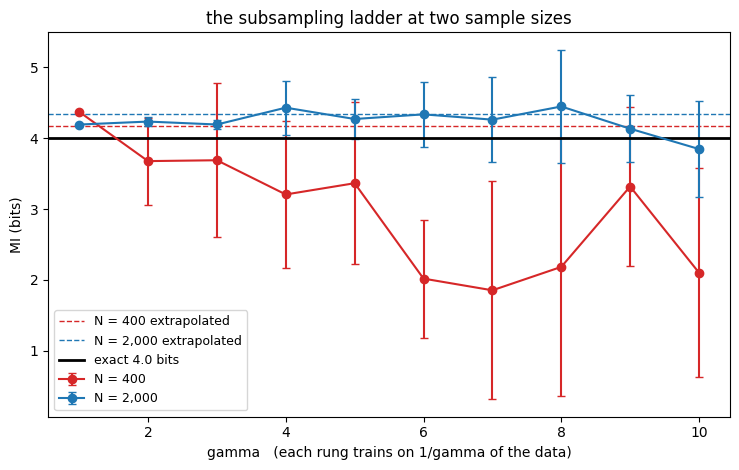

In [16]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for (n, rg), colour in zip(rigs.items(), ('tab:red', 'tab:blue')):
    # Every network of the ladder, one row per gamma and chunk.
    ladder = rg.details[0]['trainings'].groupby('gamma')['train_mi'].agg(['mean', 'std'])
    ax.errorbar(ladder.index, ladder['mean'], yerr=ladder['std'].fillna(0),
                fmt='o-', capsize=3, color=colour, label=f'N = {n:,}')
    ax.axhline(rg.mi_estimate, color=colour, ls='--', lw=1,
               label=f'N = {n:,} extrapolated')
ax.axhline(TRUE_MI, color='k', lw=2, label=f'exact {TRUE_MI:.1f} bits')
ax.set_xlabel('gamma   (each rung trains on 1/gamma of the data)')
ax.set_ylabel('MI (bits)')
ax.set_title('the subsampling ladder at two sample sizes')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

**Note:** The results object can plot itself. `rigs[400].plot()` or
`rigs[2000].plot()` gives a quick view.

At the starved size the rungs fall as the subsets shrink. That slope is the
finite-sample bias that the extrapolation fits to pull the answer back towards
the truth.

At the baseline size the rungs are flat and noisy with almost no trend for a
line to explain. `r_squared` comes out near zero for that reason. The
extrapolation there moved the answer away from the truth and returned an
interval that excludes it. It still reported `is_reliable` as `True`. With data
to spare and no need for a precise confidence interval, estimate once with
`mode='estimate'` and skip the 55 runs that `mode='rigorous'` costs by default.

`mode='rigorous'` pays for itself where there is
a slope to remove and adds noise where there is not.

## The protocol

**1. The quantity and its units.** What is being estimated, over what offsets
and windows (if any), in what units, and what bounds it. Notebook 03 explains
that.

**2. Validated against a known value.** A controlled setting where the answer
is known. You see what correct looks like for this quantity at this sample size
and this dimension.

**3. A control.** Something that could have refuted the claim and did not. A
condition where the effect should be absent, a variable that carries nothing, a
population that should not see the signal.

**4. The spread.**
- **Variance** comes from retraining across seeds, needs no ground truth and
  decides whether a value can be read at all. That's what we showed in section
  5.
- **Bias** is the finite-sample offset that shrinks as the data grows. That's
  what we showed in section 6.
- **Fragility** is the share of the components' error that a difference of two
  estimates inherits. As we saw here, small MI values can be noisy. Notebook 03
  defines quantities built as such a difference.

## Where this goes next

Notebook 03 asks what you are measuring before you measure it through the
catalogue of quantities, their offsets and their units. Notebook 04 asks what
your data does to the estimate once the sample axis is time.